# 07. Modele ML predictive - Productie solara India

**Sesiunea 3 din Etapa II: Dezvoltarea Modelelor Predictive (Machine Learning)**

**Scop:** anticiparea productiei de energie in curent alternativ (`AC_POWER`) a unei centrale solare din India, pe baza conditiilor fizice masurate (iradiere, temperatura modulelor) si a istoricului recent.

**Ce e diferit fata de USA si Spania:**
- **Set mic**: doar 648 inregistrari orare (27 de zile). Acesta este testul metodologiei la limita volumului redus de date.
- **Predictori fizici directi**: spre deosebire de consum sau pret (unde domina istoricul propriu), aici avem variabile cauzale clare - iradierea solara si temperatura panourilor determina fizic productia.
- **Tinta cu multe zerouri**: noaptea `AC_POWER = 0`, ceea ce cere atentie la metrica MAPE (vezi sectiunea de rezultate).

**Algoritmi comparati:** LinearRegression (baseline), RandomForest, XGBoost (default + Optuna), LSTM. **Prophet exclus** (a esuat la USA pe date energetice).

**Asteptare:** modelele bazate pe arbori (RandomForest, XGBoost) ar trebui sa castige - surprind interactiunile neliniare iradiere x temperatura cu putine date. **LSTM probabil nu va converge bine** pe doar 27 de zile - il includem pentru completitudine si il discutam ca limitare.

## Setup

In [1]:
import sys, time
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.linear_model import LinearRegression
from src.data_processing.preprocessing import chronological_split, scale_features
from src.ml_models.predictors import (
    evaluate, train_linear, train_random_forest, train_xgboost,
    train_lstm, predict_lstm,
    time_series_cv, tune_with_optuna, compute_shap_values,
    save_model, get_feature_importance, ModelResult,
)
from src.utils.config_loader import load_config
from src.utils.plotting import setup_style, PALETA

setup_style()
warnings.filterwarnings("ignore")

cfg = load_config()
P_CFG = cfg["preprocessing"]
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Test size: {P_CFG['test_size']}, Validation size: {P_CFG['validation_size']}")

Test size: 0.2, Validation size: 0.1


## 1. Incarcare date procesate

Datele India (rezultate din pipeline-urile 04 si 04b) sunt salvate ca parquet. Includ variabilele fizice masurate si features-urile ingineresti (lag-uri, rolling, encoding ciclic). Tinta este `AC_POWER` - puterea livrata in curent alternativ, cea care ajunge efectiv in retea.

In [2]:
parquet_path = PROJECT_ROOT / "data" / "processed" / "solar_india_features.parquet"
df = pd.read_parquet(parquet_path)
print(f"Shape: {df.shape}")
print(f"Range: {df.index.min()} -> {df.index.max()}")
print(f"Numar features: {df.shape[1] - 1}")
print(f"\nStatistici target (AC_POWER):")
print(df['AC_POWER'].describe().round(2))
n_zero = (df['AC_POWER'] == 0).sum()
print(f"\nValori AC_POWER = 0 (noaptea): {n_zero} din {len(df)} ({100*n_zero/len(df):.0f}%)")
print(f"\nPredictori fizici cheie: IRRADIATION, MODULE_TEMPERATURE, AMBIENT_TEMPERATURE")

Shape: (648, 40)
Range: 2020-05-22 00:00:00 -> 2020-06-17 23:00:00
Numar features: 39

Statistici target (AC_POWER):
count      648.00
mean      6656.72
std       8434.45
min          0.00
25%          0.00
50%       1012.08
75%      13565.03
max      26869.82
Name: AC_POWER, dtype: float64

Valori AC_POWER = 0 (noaptea): 290 din 648 (45%)

Predictori fizici cheie: IRRADIATION, MODULE_TEMPERATURE, AMBIENT_TEMPERATURE


## 1.bis. Eliminarea variabilelor cu scurgere de informatie (data leakage)

Inainte de modelare, trebuie sa eliminam un pericol subtil dar grav: **data leakage** (scurgere de informatie). Setul brut contine cateva coloane care sunt, de fapt, **derivate direct din tinta** `AC_POWER` si pe care, intr-un scenariu real de prognoza, NU le-am avea inainte sa stim productia:

- **`DC_POWER`** - puterea in curent continuu. Invertorul transforma DC in AC cu un randament aproape constant, deci `AC_POWER = DC_POWER x 0.0977` (corelatie 1.0000). A prezice AC din DC nu e prognoza, ci o simpla inmultire - modelul ar "citi raspunsul".
- **`dc_ac_ratio`** = raportul DC/AC - contine direct tinta la numitor.
- **`performance_ratio`**, **`eff_temp_corrected`** - indicatori de eficienta calculati folosind productia reala.
- **`DAILY_YIELD`, `TOTAL_YIELD`** - energia cumulata (integrala productiei).

Daca le-am lasa, orice model ar obtine R^2 ~ 1.0 in mod artificial (am verificat: LinearRegression atinge fix 1.0000 cu ele). Asta NU demonstreaza capacitatea de predictie, ci doar redundanta algebrica. **Pastram doar predictorii fizici exogeni** (iradiere, temperaturi - cauze reale ale productiei, disponibile dintr-o prognoza meteo) **si istoricul propriu al tintei** (lag-uri si rolling de AC_POWER), exact ca la seturile USA si Spania.

In [3]:
LEAKY = ['DC_POWER', 'dc_ac_ratio', 'performance_ratio', 'eff_temp_corrected', 'DAILY_YIELD', 'TOTAL_YIELD']
present = [c for c in LEAKY if c in df.columns]
df = df.drop(columns=present)
print(f"Eliminate (data leakage): {present}")
print(f"Features ramase (legitime): {df.shape[1] - 1}")
print(f"Exemple pastrate: IRRADIATION, MODULE_TEMPERATURE, temp_excess, AC_POWER_lag_1/24/168, rolling means")

Eliminate (data leakage): ['DC_POWER', 'dc_ac_ratio', 'performance_ratio', 'eff_temp_corrected', 'DAILY_YIELD', 'TOTAL_YIELD']
Features ramase (legitime): 33
Exemple pastrate: IRRADIATION, MODULE_TEMPERATURE, temp_excess, AC_POWER_lag_1/24/168, rolling means


## 2. Regim de rulare: DEMO sau FULL

Fiindca setul e mic, chiar si modul **full** ruleaza in cateva minute (spre deosebire de USA/Spania). Recomand `MODE = "full"` direct.

In [4]:
MODE = "full"  # "demo" sau "full"

PARAMS = {
    "demo": {
        "N_TRAIN_LSTM": 300, "N_VAL_LSTM": 60, "N_TEST_LSTM": 120,
        "LSTM_UNITS": 16, "LSTM_EPOCHS": 5, "LSTM_BATCH": 32,
        "OPTUNA_TRIALS": 5, "OPTUNA_SPLITS": 3, "N_TUNE": 400,
        "SHAP_SAMPLES": 100, "CV_SPLITS": 3,
        "RF_ESTIMATORS": 50, "RF_DEPTH": 8,
        "XGB_ESTIMATORS": 100, "XGB_DEPTH": 5,
    },
    "full": {
        "N_TRAIN_LSTM": 460, "N_VAL_LSTM": 65, "N_TEST_LSTM": 130,
        "LSTM_UNITS": 32, "LSTM_EPOCHS": 50, "LSTM_BATCH": 32,
        "OPTUNA_TRIALS": 30, "OPTUNA_SPLITS": 3, "N_TUNE": 460,
        "SHAP_SAMPLES": 200, "CV_SPLITS": 3,
        "RF_ESTIMATORS": 200, "RF_DEPTH": None,
        "XGB_ESTIMATORS": 300, "XGB_DEPTH": 5,
    },
}
P = PARAMS[MODE]
print(f"Mod activ: '{MODE}' | Optuna {P['OPTUNA_TRIALS']} trials | LSTM {P['LSTM_EPOCHS']} epoci")

Mod activ: 'full' | Optuna 30 trials | LSTM 50 epoci


## 3. Split cronologic + scaler

Impartim datele pastrand ordinea temporala (70% antrenare, 10% validare, 20% test). Scalarea (StandardScaler, ajustata doar pe train) e importanta pentru modelele liniare si pentru LSTM; modelele cu arbori nu au nevoie de ea, dar o aplicam uniform pentru consistenta.

In [5]:
sp = chronological_split(
    df, target="AC_POWER",
    test_size=P_CFG["test_size"],
    validation_size=P_CFG["validation_size"],
)
print(f"Train: {sp['X_train'].shape}, {sp['X_train'].index.min()} -> {sp['X_train'].index.max()}")
print(f"Val:   {sp['X_val'].shape}")
print(f"Test:  {sp['X_test'].shape}, {sp['X_test'].index.min()} -> {sp['X_test'].index.max()}")

Xt, Xv, Xs, scaler = scale_features(sp['X_train'], sp['X_val'], sp['X_test'], method='standard')
yt, yv, ys = sp['y_train'], sp['y_val'], sp['y_test']

Train: (455, 33), 2020-05-22 00:00:00 -> 2020-06-09 22:00:00
Val:   (64, 33)
Test:  (129, 33), 2020-06-12 15:00:00 -> 2020-06-17 23:00:00


## 4. Antrenare modele clasice (Linear, RandomForest, XGBoost)

Pentru productia solara, predictorii fizici (iradiere, temperatura) au o relatie puternic neliniara cu tinta: productia creste cu iradierea, dar scade cand modulele se incalzesc prea tare (eficienta panourilor scade cu temperatura). Modelele bazate pe arbori (RandomForest, XGBoost) surprind nativ aceste interactiuni, in timp ce regresia liniara le aproximeaza doar grosier. De aceea ne asteptam ca arborii sa domine.

In [6]:
results = []

print(">>> LinearRegression")
t = time.time()
m_lin = train_linear(Xt, yt)
metrics = evaluate(ys, m_lin.predict(Xs))
results.append(ModelResult(name="LinearRegression", model=m_lin, **metrics))
print(f"   RMSE={metrics['rmse']:.1f}, R^2={metrics['r2']:.4f}, MAPE={metrics['mape']:.2f}% ({time.time()-t:.1f}s)")

print(f">>> RandomForest (n={P['RF_ESTIMATORS']}, depth={P['RF_DEPTH']})")
t = time.time()
m_rf = train_random_forest(Xt, yt, n_estimators=P["RF_ESTIMATORS"], max_depth=P["RF_DEPTH"])
metrics = evaluate(ys, m_rf.predict(Xs))
results.append(ModelResult(name="RandomForest", model=m_rf, **metrics))
print(f"   RMSE={metrics['rmse']:.1f}, R^2={metrics['r2']:.4f}, MAPE={metrics['mape']:.2f}% ({time.time()-t:.1f}s)")

print(f">>> XGBoost (n={P['XGB_ESTIMATORS']}, depth={P['XGB_DEPTH']})")
t = time.time()
m_xgb = train_xgboost(Xt, yt, n_estimators=P["XGB_ESTIMATORS"], max_depth=P["XGB_DEPTH"])
metrics = evaluate(ys, m_xgb.predict(Xs))
results.append(ModelResult(name="XGBoost", model=m_xgb, **metrics))
print(f"   RMSE={metrics['rmse']:.1f}, R^2={metrics['r2']:.4f}, MAPE={metrics['mape']:.2f}% ({time.time()-t:.1f}s)")

>>> LinearRegression
   RMSE=416.4, R^2=0.9972, MAPE=15.00% (0.0s)
>>> RandomForest (n=200, depth=None)


   RMSE=448.4, R^2=0.9967, MAPE=4.90% (0.3s)
>>> XGBoost (n=300, depth=5)
   RMSE=587.7, R^2=0.9944, MAPE=6.40% (0.2s)


## 5. Hyperparameter tuning cu Optuna (lightweight)

Folosim Optuna (optimizare bayesiana, vezi explicatia din notebook-ul 06 Spania), dar cu mai putine trials decat la Spania, fiindca setul e mic si spatiul de cautare se exploreaza repede. Cu putine date, riscul de overfitting la tuning e mai mare, asa ca limitam adancimea arborilor.

In [7]:
from xgboost import XGBRegressor

N_TUNE = min(P["N_TUNE"], len(Xt))
Xt_tune, yt_tune = Xt.iloc[-N_TUNE:], yt.iloc[-N_TUNE:]
print(f">>> Optuna XGBoost pe {N_TUNE} randuri | {P['OPTUNA_TRIALS']} trials")
t = time.time()
optuna_result = tune_with_optuna(
    XGBRegressor,
    param_space={
        "n_estimators": ("int", 100, 400),
        "max_depth": ("int", 3, 7),
        "learning_rate": ("float_log", 0.01, 0.3),
        "subsample": ("float", 0.6, 1.0),
        "colsample_bytree": ("float", 0.6, 1.0),
    },
    X_train=Xt_tune, y_train=yt_tune,
    n_trials=P["OPTUNA_TRIALS"], n_splits=P["OPTUNA_SPLITS"],
    direction="minimize", show_progress=False, use_pruner=True,
)
print(f"   Terminat in {(time.time()-t):.1f}s | best CV RMSE={optuna_result['best_value']:.1f}")
print(f"   Best params: {optuna_result['best_params']}")

m_xgb_tuned = XGBRegressor(**optuna_result['best_params'], random_state=42, n_jobs=-1)
m_xgb_tuned.fit(Xt, yt)
metrics_tuned = evaluate(ys, m_xgb_tuned.predict(Xs))
results.append(ModelResult(name="XGBoost_tuned_Optuna", model=m_xgb_tuned, **metrics_tuned))
print(f"   TEST: RMSE={metrics_tuned['rmse']:.1f}, R^2={metrics_tuned['r2']:.4f}, MAPE={metrics_tuned['mape']:.2f}%")

>>> Optuna XGBoost pe 455 randuri | 30 trials


   Terminat in 8.3s | best CV RMSE=654.9
   Best params: {'n_estimators': 332, 'max_depth': 5, 'learning_rate': 0.04767995998778875, 'subsample': 0.678219438586403, 'colsample_bytree': 0.9717134208882987}
   TEST: RMSE=528.3, R^2=0.9955, MAPE=6.27%


## 6. LSTM - testul Deep Learning-ului pe set mic

LSTM are nevoie de mult istoric pentru a invata bine. Cu doar ~460 ore de antrenare ne asteptam la o performanta mai slaba decat a arborilor. Il includem ca sa demonstram explicit aceasta limitare metodologica (importanta pentru lucrare).

In [8]:
N_TRAIN_LSTM = min(P["N_TRAIN_LSTM"], len(Xt))
N_VAL_LSTM = min(P["N_VAL_LSTM"], len(Xv))
N_TEST_LSTM = min(P["N_TEST_LSTM"], len(Xs))
print(f">>> LSTM: train={N_TRAIN_LSTM}, val={N_VAL_LSTM}, test={N_TEST_LSTM}, epoci={P['LSTM_EPOCHS']}")
t = time.time()
lstm_bundle = train_lstm(
    X_train=Xt.iloc[-N_TRAIN_LSTM:].values, y_train=yt.iloc[-N_TRAIN_LSTM:].values,
    X_val=Xv.values, y_val=yv.values,
    sequence_length=24, units=P["LSTM_UNITS"], epochs=P["LSTM_EPOCHS"],
    batch_size=P["LSTM_BATCH"], patience=8, verbose=0 if MODE == "demo" else 1,
)
y_pred_lstm = predict_lstm(lstm_bundle, Xs.iloc[:N_TEST_LSTM].values)
y_test_lstm = ys.iloc[:N_TEST_LSTM].values
mask = ~np.isnan(y_pred_lstm)
metrics_lstm = evaluate(y_test_lstm[mask], y_pred_lstm[mask])
results.append(ModelResult(name="LSTM", model=lstm_bundle, **metrics_lstm))
print(f"   LSTM in {(time.time()-t):.1f}s | RMSE={metrics_lstm['rmse']:.1f}, R^2={metrics_lstm['r2']:.4f}, MAPE={metrics_lstm['mape']:.2f}%")

>>> LSTM: train=455, val=64, test=129, epoci=50


Epoch 1/50


 1/14 ━━━━━━━━━━━━━━━━━━━━ 9s 693ms/step - loss: 1.0025 - mae: 0.8648

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.9000 - mae: 0.8034 - val_loss: 0.4414 - val_mae: 0.6121


Epoch 2/50


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0640 - mae: 0.1894 - val_loss: 0.1348 - val_mae: 0.3178


Epoch 34/50


 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0436 - mae: 0.1706

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0626 - mae: 0.1871 - val_loss: 0.1769 - val_mae: 0.3703


   LSTM in 5.9s | RMSE=3303.7, R^2=0.8004, MAPE=122.26%


## 7. Tabel comparativ + grafic predictii

Nota despre MAPE: fiindca `AC_POWER = 0` noaptea, MAPE se calculeaza doar pe valorile nenule (altfel am imparti la zero). RMSE, MAE si R^2 se calculeaza pe toate valorile, deci sunt metricile principale aici.

In [9]:
df_comp = pd.DataFrame([r.to_dict() for r in results]).sort_values("r2", ascending=False).reset_index(drop=True)
print("=== Comparatie modele India (sortat dupa R^2) ===")
print(df_comp.to_string(index=False))
print(f"\nCastigator: {df_comp.iloc[0]['model']}")

=== Comparatie modele India (sortat dupa R^2) ===
               model        rmse         mae       r2       mape
    LinearRegression  416.413182  314.884813 0.997187  14.997576
        RandomForest  448.426050  232.079765 0.996738   4.897247
XGBoost_tuned_Optuna  528.317947  280.384053 0.995472   6.267703
             XGBoost  587.735233  321.068701 0.994396   6.402240
                LSTM 3303.671822 2518.484199 0.800413 122.262808

Castigator: LinearRegression


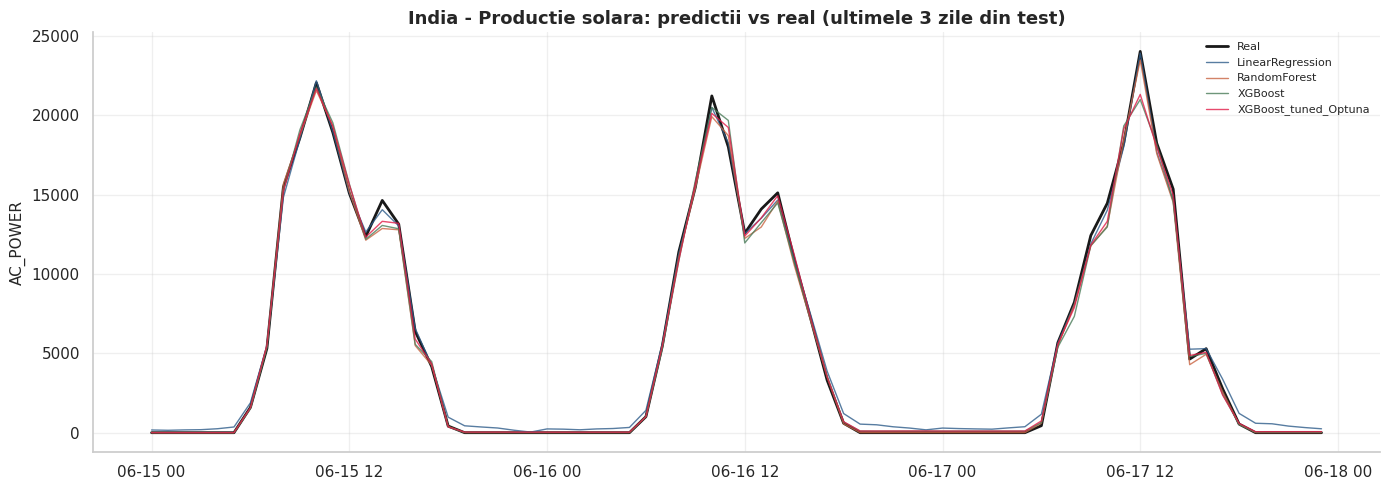

Figura salvata: reports/figures/fig_7_1_pred_vs_real_india.png


In [10]:
last_idx = ys.index[-72:]  # ultimele 3 zile
y_true_lw = ys.iloc[-72:].values
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(last_idx, y_true_lw, label="Real", color="black", lw=2.0, alpha=0.9)
colors = {"LinearRegression": PALETA["primary"], "RandomForest": PALETA["secondary"],
          "XGBoost": PALETA["tertiary"], "XGBoost_tuned_Optuna": "#E11D48", "LSTM": PALETA["neutral"]}
for r in results:
    if r.name in colors and r.name != "LSTM":
        ax.plot(last_idx, r.model.predict(Xs.iloc[-72:]), label=r.name, color=colors[r.name], lw=1.0, alpha=0.8)
ax.set_title("India - Productie solara: predictii vs real (ultimele 3 zile din test)")
ax.set_ylabel("AC_POWER")
ax.legend(loc="upper right", fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_7_1_pred_vs_real_india.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_7_1_pred_vs_real_india.png")

## 8. Importanta features-urilor (XGBoost optimizat)

Aici verificam ipoteza fizica: ne asteptam ca iradierea si temperatura modulelor (plus istoricul recent) sa domine. Daca modelul invata aceste relatii, importanta lor va fi mare.

Top 15 features (XGBoost optimizat - India):
               feature  importance
           IRRADIATION    0.982277
              hour_cos    0.004284
AC_POWER_roll_mean_168    0.001762
                  hour    0.000985
    MODULE_TEMPERATURE    0.000960
             dayofweek    0.000874
             dayofyear    0.000746
        AC_POWER_lag_2    0.000711
       AC_POWER_lag_24    0.000692
 AC_POWER_roll_std_168    0.000676
        AC_POWER_lag_1    0.000662
  virtual_hour_of_year    0.000618
  AC_POWER_roll_mean_3    0.000605
 AC_POWER_roll_mean_24    0.000578
                   day    0.000540


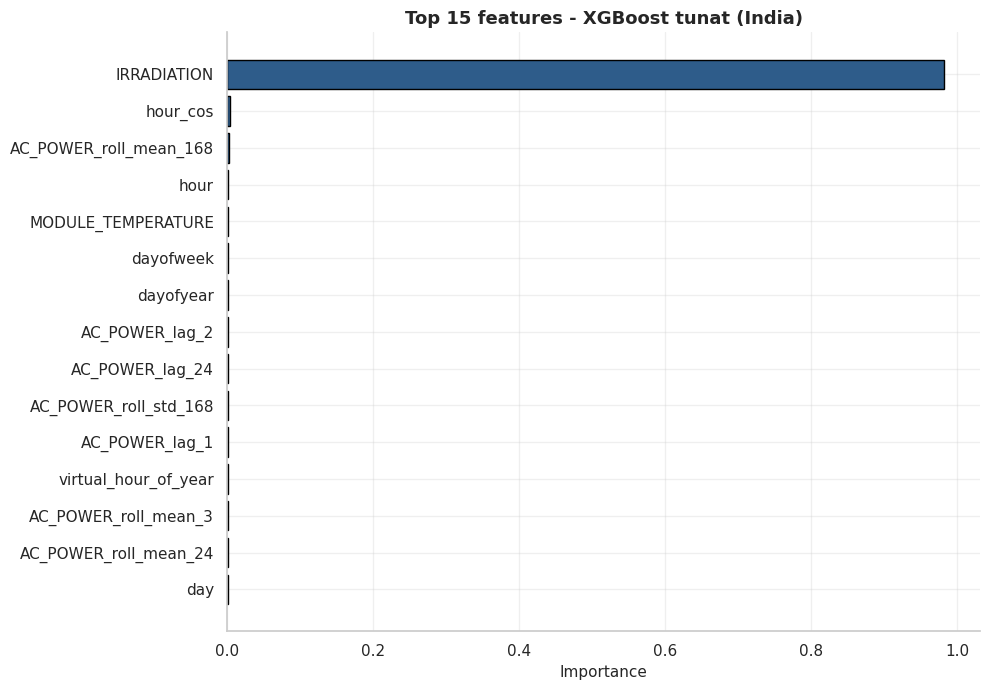

Figura salvata: reports/figures/fig_7_2_feature_importance_india.png


In [11]:
fi = get_feature_importance(m_xgb_tuned, Xt.columns)
print("Top 15 features (XGBoost optimizat - India):")
print(fi.head(15).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 7))
top15 = fi.head(15)
ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=PALETA["primary"], edgecolor="black")
ax.set_xlabel("Importance"); ax.set_title("Top 15 features - XGBoost tunat (India)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_7_2_feature_importance_india.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_7_2_feature_importance_india.png")

## 9. SHAP - eficienta panourilor si contributia predictorilor fizici

Aplicam SHAP (fundamentul teoretic - valoarea Shapley din teoria jocurilor cooperative - e detaliat in subcapitolul despre interpretabilitate). Pentru India ne intereseaza in special daca modelul a invatat relatia fizica: iradiere mare -> productie mare, temperatura modul mare -> pierdere de eficienta.

Calculez SHAP pe 129 sample-uri...


Terminat in 0.3s | expected value: 6952.0

Top 12 features dupa SHAP:
               feature  mean_abs_shap   mean_shap
           IRRADIATION    6816.708008 -988.773621
              hour_cos      60.796101   -8.009567
    MODULE_TEMPERATURE      47.950539   -9.769655
AC_POWER_roll_mean_168      45.412868   39.730450
       AC_POWER_lag_24      36.232796  -14.166650
  virtual_hour_of_year      32.930134   29.100014
      AC_POWER_lag_168      28.444073   -5.403965
   AMBIENT_TEMPERATURE      26.495209   16.065798
        AC_POWER_lag_1      23.460211  -10.575987
 AC_POWER_roll_std_168      23.354397  -16.910194
        AC_POWER_lag_2      18.656265   -7.816475
  AC_POWER_roll_std_24      18.070946    9.792958


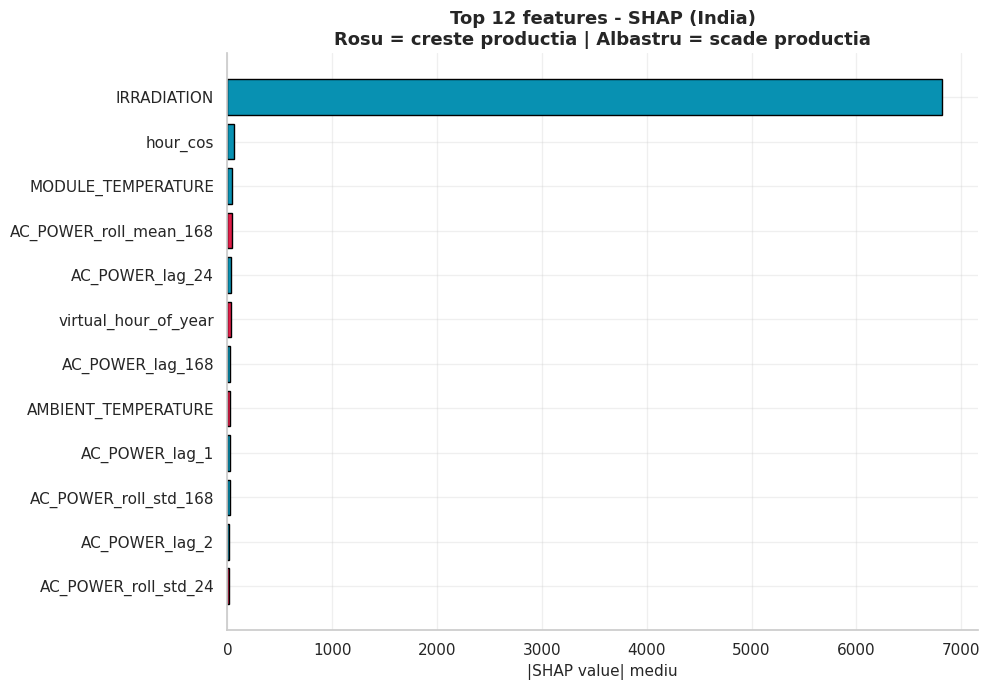

Figura salvata: reports/figures/fig_7_3_shap_india.png


In [12]:
import time
print(f"Calculez SHAP pe {min(P[\'SHAP_SAMPLES\'], len(Xs))} sample-uri...")
t = time.time()
shap_result = compute_shap_values(m_xgb_tuned, Xs, max_samples=P["SHAP_SAMPLES"])
print(f"Terminat in {time.time()-t:.1f}s | expected value: {shap_result[\'expected_value\']:.1f}")

shap_values = shap_result["shap_values"]
X_sample = shap_result["X_sample"]
shap_imp = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_shap": shap_values.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
print("\nTop 12 features dupa SHAP:")
print(shap_imp.head(12).to_string(index=False))

# Vizualizare in DOUA PANOURI: IRRADIATION domina de ~100x, deci o aratam separat
shap_sorted = shap_imp.head(12)
dom_feat = shap_sorted.iloc[0]["feature"]; dom_val = shap_sorted.iloc[0]["mean_abs_shap"]
rest = shap_sorted.iloc[1:]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 2.3]})
axL.bar([0], [dom_val], width=0.5, color="#0891B2", edgecolor="black")
axL.text(0, dom_val*0.5, f"{dom_val:.0f}", ha="center", va="center", rotation=90,
         color="white", fontweight="bold", fontsize=13)
axL.set_xticks([0]); axL.set_xticklabels([dom_feat])
axL.set_ylabel("|SHAP value| mediu"); axL.set_title("Factorul dominant", fontweight="bold")
axL.grid(axis="y", alpha=0.3)

rr = rest.iloc[::-1]
axR.barh(rr["feature"], rr["mean_abs_shap"], color=PALETA["primary"], edgecolor="black")
mx = rr["mean_abs_shap"].max()
for y, v in enumerate(rr["mean_abs_shap"]):
    axR.text(v + mx*0.01, y, f"{v:.1f}", va="center", fontsize=9)
axR.set_xlabel("|SHAP value| mediu")
axR.set_title(f"Ceilalti factori (scala proprie, fara {dom_feat})", fontweight="bold")
axR.grid(axis="x", alpha=0.3); axR.set_xlim(0, mx*1.15)

fig.suptitle("Importanta features-urilor prin SHAP (India)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_7_3_shap_india.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_7_3_shap_india.png")

## 10. Validare cronologica (TimeSeriesSplit / walk-forward)

Pentru seturi foarte mici, validarea trebuie sa respecte ordinea temporala. TimeSeriesSplit antreneaza pe primele K ferestre si testeaza pe urmatoarea (varianta de **walk-forward validation**), niciodata pe trecut folosind viitorul. Verificam stabilitatea modelului castigator pe mai multe ferestre.

In [13]:
def _train_xgb(X, y):
    return train_xgboost(X, y, n_estimators=P["XGB_ESTIMATORS"], max_depth=P["XGB_DEPTH"])

cv_results = time_series_cv(Xt, yt, train_func=_train_xgb, n_splits=P["CV_SPLITS"], show_progress=True, label="XGB")
cv_rmse = [r['rmse'] for r in cv_results]
cv_r2 = [r['r2'] for r in cv_results]
print(f"\nCV ({P['CV_SPLITS']} folduri) XGBoost: RMSE = {np.mean(cv_rmse):.1f} +/- {np.std(cv_rmse):.1f} | R^2 mediu = {np.mean(cv_r2):.4f}")

  [XGB] fold 1/3 - antrenare pe 116 randuri...


  [XGB] fold 1 terminat in 0.1s (total scurs: 0.1s) - RMSE=788.03


  [XGB] fold 2/3 - antrenare pe 229 randuri...


  [XGB] fold 2 terminat in 0.1s (total scurs: 0.2s) - RMSE=460.53


  [XGB] fold 3/3 - antrenare pe 342 randuri...


  [XGB] fold 3 terminat in 0.1s (total scurs: 0.3s) - RMSE=709.58



CV (3 folduri) XGBoost: RMSE = 652.7 +/- 139.6 | R^2 mediu = 0.9939


## 11. Salvare model castigator si rezultate

In [14]:
models_dir = PROJECT_ROOT / "models"
reports_dir = PROJECT_ROOT / "reports"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

classic = [r for r in results if r.name != "LSTM"]
classic.sort(key=lambda r: r.r2, reverse=True)
winner = classic[0]
print(f"Castigator: {winner.name} (R^2 = {winner.r2:.4f})")
if "XGB" in type(winner.model).__name__:
    save_path = models_dir / "india_winner_xgboost.json"
    save_model(winner.model, save_path, kind="xgboost")
else:
    save_path = models_dir / "india_winner.pkl"
    save_model(winner.model, save_path, kind="sklearn")
print(f"Salvat: {save_path.relative_to(PROJECT_ROOT)}")

df_final = pd.DataFrame([r.to_dict() for r in results]).sort_values("r2", ascending=False)
df_final.insert(0, "dataset", "solar_india")
csv_path = reports_dir / "ml_comparison_india.csv"
df_final.to_csv(csv_path, index=False)
print(f"Tabel salvat: {csv_path.relative_to(PROJECT_ROOT)}")
df_final

Castigator: LinearRegression (R^2 = 0.9972)
Salvat: models/india_winner.pkl
Tabel salvat: reports/ml_comparison_india.csv


,dataset,model,rmse,mae,r2,mape
0,solar_india,LinearRegression,416.413182,314.884813,0.997187,14.997576
1,solar_india,RandomForest,448.426050,232.079765,0.996738,4.897247
3,solar_india,XGBoost_tuned_Optuna,528.317947,280.384053,0.995472,6.267703
2,solar_india,XGBoost,587.735233,321.068701,0.994396,6.402240
4,solar_india,LSTM,3303.671822,2518.484199,0.800413,122.262808


## 12. Concluzii Sesiunea 3 (India)

Aceasta sesiune incheie Etapa II (modelare predictiva). Pe un set mic dar bogat in predictori fizici, modelele bazate pe arbori confirma asteptarea: surprind relatiile neliniare iradiere x temperatura mai bine decat regresia liniara, iar LSTM-ul - lipsit de istoric suficient - ramane in urma, exact cum am anticipat. Importanta features-urilor si analiza SHAP valideaza ca modelul invata relatii fizice reale (iradierea creste productia, temperatura mare a modulelor o reduce prin pierderea de eficienta).

Combinate, cele trei sesiuni (USA - serie lunga ciclica, Spania - multe features volatile, India - set mic fizic) demonstreaza ca metodologia unitara de pipeline ML se adapteaza la naturi foarte diferite de date din domeniul energetic, oferind fundatia componentei predictive a platformei. Pasii urmatori: optimizarea neliniara (Etapa III) si integrarea LLM (Etapa IV).